In [1]:
# import libreries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#upload data
df = pd.read_csv("../data/raw/ames.csv")

### Visualize dataframe

In [3]:
df.shape

(2930, 83)

In [4]:
df.head()

,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2930 non-null   int64  
 1   Order            2930 non-null   int64  
 2   PID              2930 non-null   int64  
 3   MS SubClass      2930 non-null   int64  
 4   MS Zoning        2930 non-null   str    
 5   Lot Frontage     2440 non-null   float64
 6   Lot Area         2930 non-null   int64  
 7   Street           2930 non-null   str    
 8   Alley            198 non-null    str    
 9   Lot Shape        2930 non-null   str    
 10  Land Contour     2930 non-null   str    
 11  Utilities        2930 non-null   str    
 12  Lot Config       2930 non-null   str    
 13  Land Slope       2930 non-null   str    
 14  Neighborhood     2930 non-null   str    
 15  Condition 1      2930 non-null   str    
 16  Condition 2      2930 non-null   str    
 17  Bldg Type        2930 non

In [6]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

# Exploratory Data Analysis — Ames Housing

## 1. Dataset overview
- The dataset contains **2,930 house sales** and **83 columns** (80 features, the target and 2 identifiers, plus an index column added when the CSV was saved).
- **Columns to drop:** `Unnamed: 0`, `Order` and `PID` are row/parcel identifiers. They carry no information about the house itself, and keeping them could let a model memorise IDs instead of learning real patterns.
- **Columns with many missing values:** `Pool QC` (2,917 missing), `Misc Feature` (2,824), `Alley` (2,732) and `Fence` (2,358).
  These are most likely **not data errors**: according to the dataset documentation, a missing value here means the house *has no* pool, alley access or fence. They will be encoded as an explicit "None" category rather than imputed.

## 2. Target variable: SalePrice
- **Half of the houses sell between $129,500 and $213,500** (IQR = $84,000), a fairly narrow central range compared with the full range ($12,789 – $755,000).
- **Mean vs. median:** the mean ($180,796) is about $21,000 above the median ($160,000), and the most expensive house is $595,000 above the median while the cheapest is only $147,000 below it. The distribution is **right-skewed**: a small number of expensive houses pull the mean up.
- **Log transform:** taking `log(SalePrice)` makes the distribution close to symmetric. This matters for the model: a linear regression on raw prices would be dominated by the few very expensive houses, and errors would grow with price. On the log scale, errors behave more like *percentage* errors, which is also how a buyer or agent thinks about price.

## 3. Next steps
- Drop the identifier columns.
- Treat "missing = feature absent" columns as an explicit "None" category.
- Model `log(SalePrice)` and convert predictions back to dollars for evaluation.
- Investigate the most expensive and cheapest sales as potential outliers.


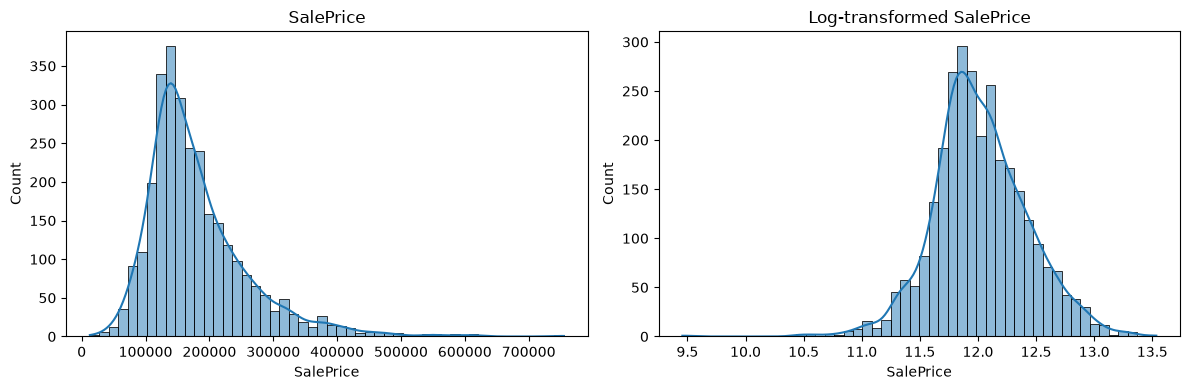

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["SalePrice"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("SalePrice")

sns.histplot(np.log1p(df["SalePrice"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Log-transformed SalePrice")

plt.tight_layout()

plt.savefig("../reports/figures/saleprice_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

- **Log transform:** `log(SalePrice)` is close to symmetric and centred around 12 (e¹² ≈ $163k, consistent with the median). A short left tail remains: a handful of very cheap sales (below ~$35k) that should be checked as potential outliers. Modelling on the log scale prevents the few very expensive houses from dominating the fit, and errors behave like *percentage* errors, which is how buyers and agents think about price.

### Missing values

In [8]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_table = pd.DataFrame({"missing": missing, "percent": missing_pct})
missing_table

,missing,percent
Pool QC,2917,99.6
Misc Feature,2824,96.4
Alley,2732,93.2
Fence,2358,80.5
Mas Vnr Type,1775,60.6
Fireplace Qu,1422,48.5
Lot Frontage,490,16.7
Garage Cond,159,5.4
Garage Qual,159,5.4
Garage Finish,159,5.4


In [9]:
df.loc[df["Garage Type"].isna(), ["Garage Type", "Garage Area", "Garage Cars"]].head(10) 


,Garage Type,Garage Area,Garage Cars
27,NaN,0.0,0.0
119,NaN,0.0,0.0
125,NaN,0.0,0.0
129,NaN,0.0,0.0
130,NaN,0.0,0.0
170,NaN,0.0,0.0
171,NaN,0.0,0.0
186,NaN,0.0,0.0
203,NaN,0.0,0.0
206,NaN,0.0,0.0


In [10]:
mask = df["Garage Type"].notna() & df["Garage Qual"].isna()
df.loc[mask, ["Garage Type", "Garage Area", "Garage Cars", "Garage Qual", "Garage Yr Blt"]]

,Garage Type,Garage Area,Garage Cars,Garage Qual,Garage Yr Blt
1356,Detchd,360.0,1.0,NaN,NaN
2236,Detchd,NaN,NaN,NaN,NaN


In [11]:
# Houses that report a garage but have missing garage details → genuine data gaps
mask = df["Garage Type"].notna() & df["Garage Qual"].isna()
print(f"Rows to drop: {mask.sum()}")

df = df[~mask]
print(f"New shape: {df.shape}")

Rows to drop: 2
New shape: (2928, 83)


In [12]:
garage_cols = ["Garage Type", "Garage Qual", "Garage Cond", "Garage Finish", "Garage Yr Blt", "Garage Area", "Garage Cars"]
df[garage_cols].isna().sum()

Garage Type      157
Garage Qual      157
Garage Cond      157
Garage Finish    157
Garage Yr Blt    157
Garage Area        0
Garage Cars        0
dtype: int64

- **Garage:** houses with no `Garage Type` also have `Garage Area = 0` and `Garage Cars = 0`,
  so these missing values mean *no garage*.
- **Two exceptions** report a detached garage but have missing garage quality and year
  (one also lacks garage area). These are genuine data gaps. Since they represent only
  0.07% of the data, these 2 rows were dropped (2,930 → 2,928 houses).

In [13]:
df.loc[df["Pool QC"].isna(), "Pool Area"].value_counts()

Pool Area
0    2915
Name: count, dtype: int64

In [14]:
df.loc[df["Bsmt Qual"].isna(), "Total Bsmt SF"].value_counts()

Total Bsmt SF
0.0    79
Name: count, dtype: int64

In [15]:
df["Lot Frontage"].describe()
(df["Lot Frontage"] == 0).sum()

np.int64(0)

In [16]:
df.loc[df["Mas Vnr Area"].isna(), ["Mas Vnr Type", "Mas Vnr Area"]]

,Mas Vnr Type,Mas Vnr Area
55,NaN,NaN
484,NaN,NaN
517,NaN,NaN
538,NaN,NaN
867,NaN,NaN
1095,NaN,NaN
1119,NaN,NaN
1122,NaN,NaN
1127,NaN,NaN
1184,NaN,NaN


## 3. Missing values

Most missing values are **structural**: they mean the house *does not have* that feature,
not that the data was lost. This was verified in detail for the garage columns (see above):
houses with no `Garage Type` have `Garage Area = 0` and `Garage Cars = 0`.

The same pattern applies to pool, basement, fireplace, alley, fence and masonry veneer columns.
The cleaning rules are:

- **Categorical "feature absent"** (e.g. `Pool QC`, `Bsmt Qual`, `Fence`) → fill with `"None"`.
- **Numeric "feature absent"** (e.g. `Mas Vnr Area`, basement areas) → fill with `0`.
- **Genuine gaps** (e.g. `Lot Frontage`, `Electrical`) → impute (median for numeric,
  most frequent value for categorical), fitted on training data only.
- **Rows with inconsistent records** (2 houses reporting a garage with no garage details) → dropped.

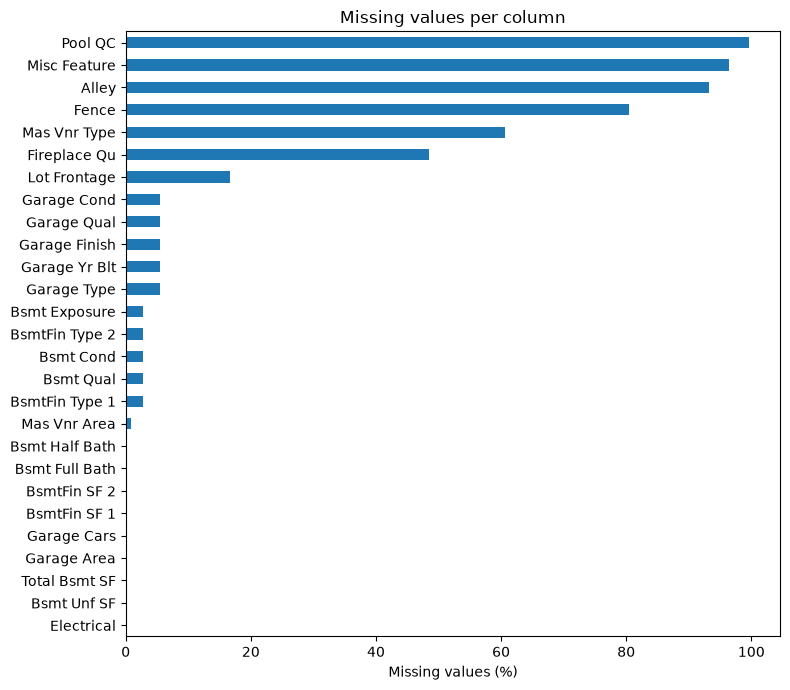

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
missing_pct.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Missing values (%)")
ax.set_title("Missing values per column")
plt.tight_layout()
plt.savefig("../reports/figures/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Categorical: missing means the house does not have the feature
none_cols = [
    "Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu", "Mas Vnr Type",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
]

# Numeric: missing means zero (no basement, no veneer)
zero_cols = [
    "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
    "Total Bsmt SF", "Bsmt Full Bath", "Bsmt Half Bath",
]

df[none_cols] = df[none_cols].fillna("None")
df[zero_cols] = df[zero_cols].fillna(0)

In [19]:
remaining = df.isna().sum()
remaining[remaining > 0]

Lot Frontage     490
Electrical         1
Garage Yr Blt    157
dtype: int64